In [1]:
# ============================================================
# DAY 12 – TELEMETRY DASHBOARD / CHAT INTERFACE
# Setup
# ============================================================

import pandas as pd
import numpy as np

np.random.seed(42)

# -----------------------------
# 1. Define regions
# -----------------------------

regions = ["Region A", "Region B", "Region C"]

# -----------------------------
# 2. Create telemetry data
# -----------------------------

timestamps = pd.date_range(
    start="2026-01-01",
    periods=24 * 7,
    freq="h"
)

data_list = []

base_loads = {
    "Region A": 500,
    "Region B": 650,
    "Region C": 800
}

for region in regions:

    for timestamp in timestamps:

        temperature = 25 + np.random.normal(0, 2)

        power = (
            base_loads[region]
            + 40 * np.sin(2 * np.pi * timestamp.hour / 24)
            + 5 * temperature
            + np.random.normal(0, 15)
        )

        data_list.append({
            "timestamp": timestamp,
            "region": region,
            "temperature": temperature,
            "power_mw": power
        })

data = pd.DataFrame(data_list)

# -----------------------------
# 3. Create forecast data
# -----------------------------

forecast_data = []

for region in regions:

    latest_power = (
        data[data["region"] == region]
        .sort_values("timestamp")
        .iloc[-1]["power_mw"]
    )

    forecast_power = latest_power + np.random.normal(0, 10)

    forecast_data.append({
        "region": region,
        "forecast_mw": forecast_power
    })

forecast = pd.DataFrame(forecast_data)

print("=" * 60)
print("DAY 12 SETUP COMPLETED")
print("=" * 60)

print("\nRegions:", regions)
print("Telemetry Records:", len(data))

print("\nTelemetry Data Preview:")
print(data.head())

print("\nForecast Data:")
print(forecast)

DAY 12 SETUP COMPLETED

Regions: ['Region A', 'Region B', 'Region C']
Telemetry Records: 504

Telemetry Data Preview:
            timestamp    region  temperature    power_mw
0 2026-01-01 00:00:00  Region A    25.993428  627.893177
1 2026-01-01 01:00:00  Region A    26.295377  664.675095
2 2026-01-01 02:00:00  Region A    24.531693  639.146412
3 2026-01-01 03:00:00  Region A    28.158426  680.587920
4 2026-01-01 04:00:00  Region A    24.061051  663.084673

Forecast Data:
     region  forecast_mw
0  Region A   632.688102
1  Region B   740.654885
2  Region C   946.300688


REGIONAL POWER TELEMETRY DASHBOARD

Latest Telemetry:
  region  power_mw  temperature
Region B    746.01        27.49
Region A    622.19        26.95
Region C    933.13        26.79


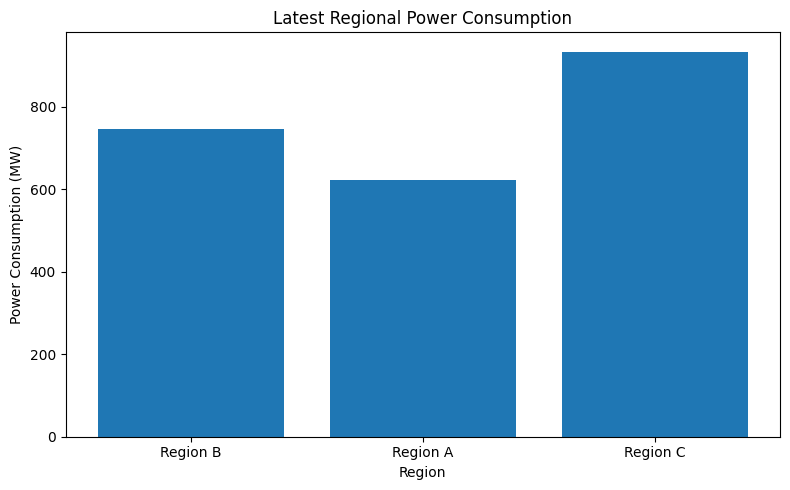

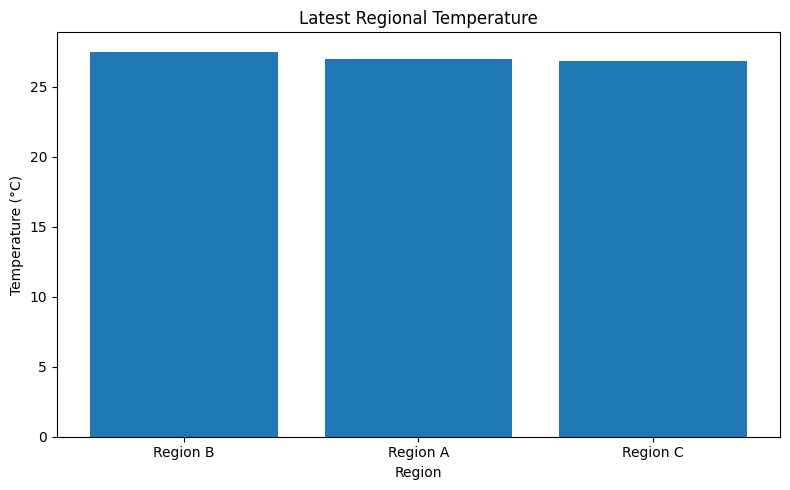

In [2]:
# ============================================================
# DAY 12 – TELEMETRY DASHBOARD
# ============================================================

import matplotlib.pyplot as plt

# Get latest telemetry for each region
latest_data = (
    data.sort_values("timestamp")
    .groupby("region")
    .tail(1)
    .copy()
)

print("=" * 60)
print("REGIONAL POWER TELEMETRY DASHBOARD")
print("=" * 60)

print("\nLatest Telemetry:")
print(
    latest_data[
        ["region", "power_mw", "temperature"]
    ].round(2).to_string(index=False)
)

# -----------------------------
# Power Consumption Chart
# -----------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    latest_data["region"],
    latest_data["power_mw"]
)

plt.title("Latest Regional Power Consumption")
plt.xlabel("Region")
plt.ylabel("Power Consumption (MW)")

plt.tight_layout()
plt.show()

# -----------------------------
# Temperature Chart
# -----------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    latest_data["region"],
    latest_data["temperature"]
)

plt.title("Latest Regional Temperature")
plt.xlabel("Region")
plt.ylabel("Temperature (°C)")

plt.tight_layout()
plt.show()

In [4]:
# ============================================================
# DAY 12 – CHAT-STYLE QUERY INTERFACE
# ============================================================

def identify_intent(query):
    query_lower = query.lower()
    if "forecast" in query_lower or "prediction" in query_lower:
        return "POWER_FORECAST"
    elif "temperature" in query_lower or "temp" in query_lower:
        return "TEMPERATURE"
    elif "power" in query_lower or "consumption" in query_lower or "usage" in query_lower:
        return "POWER_USAGE"
    return "UNKNOWN"

def extract_region(query):
    query_lower = query.lower()
    if "region a" in query_lower:
        return "Region A"
    elif "region b" in query_lower:
        return "Region B"
    elif "region c" in query_lower:
        return "Region C"
    return None

def grid_chat(query):

    intent = identify_intent(query)
    region = extract_region(query)

    # Region is required
    if region is None:
        return "Please specify a region: Region A, Region B, or Region C."

    # -----------------------------
    # Power consumption
    # -----------------------------

    if intent == "POWER_USAGE":

        latest = (
            data[data["region"] == region]
            .sort_values("timestamp")
            .iloc[-1]
        )

        return (
            f"Power consumption in {region}: "
            f"{latest['power_mw']:.2f} MW"
        )

    # -----------------------------
    # Temperature
    # -----------------------------

    elif intent == "TEMPERATURE":

        latest = (
            data[data["region"] == region]
            .sort_values("timestamp")
            .iloc[-1]
        )

        return (
            f"Temperature in {region}: "
            f"{latest['temperature']:.2f} °C"
        )

    # -----------------------------
    # Forecast
    # -----------------------------

    elif intent == "POWER_FORECAST":

        forecast_row = forecast[
            forecast["region"] == region
        ]

        prediction = forecast_row.iloc[0]["forecast_mw"]

        return (
            f"Forecasted power consumption in {region}: "
            f"{prediction:.2f} MW"
        )

    # -----------------------------
    # Unknown query
    # -----------------------------

    else:

        return (
            "I could not understand the query. "
            "You can ask about power consumption, "
            "temperature, or power forecast."
        )


# -----------------------------
# Test chat interface
# -----------------------------

print("=" * 60)
print("GRID TELEMETRY CHAT ASSISTANT")
print("=" * 60)

queries = [
    "What is the power consumption in Region A?",
    "What is the temperature in Region B?",
    "Give me the forecast for Region C."
]

for query in queries:

    print("\nOperator:", query)
    print("Assistant:", grid_chat(query))

GRID TELEMETRY CHAT ASSISTANT

Operator: What is the power consumption in Region A?
Assistant: Power consumption in Region A: 622.19 MW

Operator: What is the temperature in Region B?
Assistant: Temperature in Region B: 27.49 °C

Operator: Give me the forecast for Region C.
Assistant: Forecasted power consumption in Region C: 946.30 MW


In [5]:
# ============================================================
# DAY 12 – INTERACTIVE GRID CHAT
# ============================================================

from IPython.display import display
import ipywidgets as widgets

# Create input box
query_box = widgets.Text(
    placeholder="Enter a grid telemetry query...",
    description="Operator:",
    layout=widgets.Layout(width="80%")
)

# Create button
submit_button = widgets.Button(
    description="Ask Assistant"
)

# Create output area
chat_output = widgets.Output()

# Button action
def process_query(button):

    with chat_output:

        chat_output.clear_output()

        query = query_box.value.strip()

        if query == "":
            print("Please enter a query.")
            return

        response = grid_chat(query)

        print("Operator:", query)
        print("Assistant:", response)


submit_button.on_click(process_query)

# Display interface
display(query_box)
display(submit_button)
display(chat_output)

Text(value='', description='Operator:', layout=Layout(width='80%'), placeholder='Enter a grid telemetry query.…

Button(description='Ask Assistant', style=ButtonStyle())

Output()

REGIONAL POWER FORECAST DASHBOARD

Forecast Results:
  region  forecast_mw
Region A       632.69
Region B       740.65
Region C       946.30


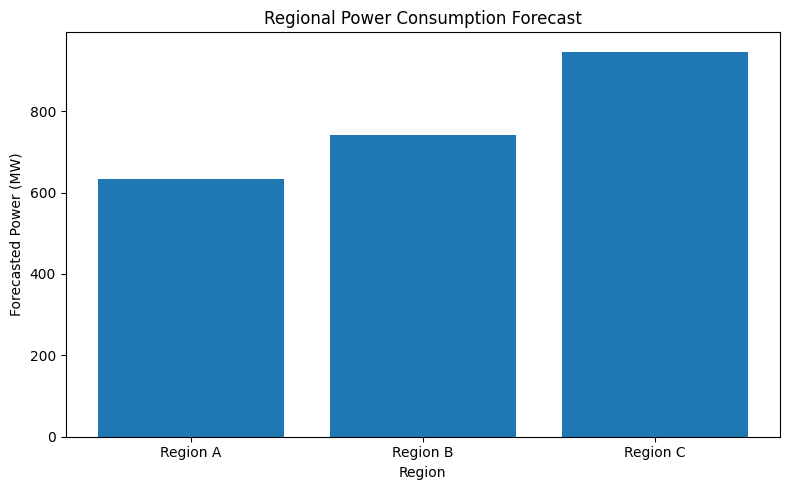

In [7]:
# ============================================================
# DAY 12 – REGIONAL FORECAST DASHBOARD
# ============================================================

forecast_dashboard = forecast.copy()

forecast_dashboard["forecast_mw"] = (
    forecast_dashboard["forecast_mw"].round(2)
)

print("=" * 60)
print("REGIONAL POWER FORECAST DASHBOARD")
print("=" * 60)

print("\nForecast Results:")
print(forecast_dashboard.to_string(index=False))

# -----------------------------
# Forecast Chart
# -----------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    forecast_dashboard["region"],
    forecast_dashboard["forecast_mw"]
)

plt.title("Regional Power Consumption Forecast")
plt.xlabel("Region")
plt.ylabel("Forecasted Power (MW)")

plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# DAY 12 – COMPLETE DASHBOARD TEST
# ============================================================

print("=" * 70)
print("DATA DYNAMO – DAY 12 COMPLETE SYSTEM TEST")
print("=" * 70)

# ---------------------
# 1. Telemetry Summary
# ---------------------

latest_data = (
    data.sort_values("timestamp")
    .groupby("region")
    .tail(1)
)

print("\n1. LATEST TELEMETRY")
print("-" * 70)

print(
    latest_data[
        ["region", "power_mw", "temperature"]
    ].round(2).to_string(index=False)
)

# ---------------------
# 2. Forecast Summary
# ---------------------

print("\n2. POWER FORECAST")
print("-" * 70)

print(
    forecast[
        ["region", "forecast_mw"]
    ].round(2).to_string(index=False)
)

# ---------------------
# 3. Chat Query Test
# ---------------------

print("\n3. NATURAL-LANGUAGE QUERY TEST")
print("-" * 70)

test_queries = [
    "What is the power consumption in Region A?",
    "What is the temperature in Region B?",
    "Give me the forecast for Region C."
]

for query in test_queries:

    print("\nOperator:", query)
    print("Assistant:", grid_chat(query))

print("\n" + "=" * 70)
print("DAY 12 COMPLETE SYSTEM TEST PASSED")
print("=" * 70)

DATA DYNAMO – DAY 12 COMPLETE SYSTEM TEST

1. LATEST TELEMETRY
----------------------------------------------------------------------
  region  power_mw  temperature
Region B    746.01        27.49
Region A    622.19        26.95
Region C    933.13        26.79

2. POWER FORECAST
----------------------------------------------------------------------
  region  forecast_mw
Region A       632.69
Region B       740.65
Region C       946.30

3. NATURAL-LANGUAGE QUERY TEST
----------------------------------------------------------------------

Operator: What is the power consumption in Region A?
Assistant: Power consumption in Region A: 622.19 MW

Operator: What is the temperature in Region B?
Assistant: Temperature in Region B: 27.49 °C

Operator: Give me the forecast for Region C.
Assistant: Forecasted power consumption in Region C: 946.30 MW

DAY 12 COMPLETE SYSTEM TEST PASSED


# Day 12 Summary

## Completed Tasks

- Created a regional telemetry dashboard.
- Displayed the latest power consumption for each region.
- Displayed regional temperature information.
- Added a regional power forecast dashboard.
- Created a natural-language grid chat assistant.
- Created an interactive operator query interface.
- Connected telemetry data and forecast results with the chat interface.
- Tested power consumption, temperature, and forecast queries.
- Performed a complete Day 12 system test.

## Dashboard Features

The dashboard provides:

- Regional power consumption
- Regional temperature
- Regional power forecast
- Natural-language query processing
- Interactive operator chat interface

## Example Queries

- "What is the power consumption in Region A?"
- "What is the temperature in Region B?"
- "Give me the forecast for Region C."

## Day 12 Outcome

A simple telemetry dashboard and chat interface was developed for grid operators. The interface allows operators to enter natural-language questions and receive power consumption, temperature, and forecast information for different regions.

## Status

**Day 12 - Completed**